Features to engineer:

days_to_first_funding = first_funding_at - founded_at
startup_age
market_missing
category_missing
country_missing
single_funding_event = (first_funding_at == last_funding_at)
funding_stage_reached (ordinal: none → seed → A → B) — capped deliberately at B. This replaces raw round_B amount and stops the model from treating "reached B" as a crystal ball.
has_institutional_vc (binary, derived from venture being nonzero) — captures "professional investors are in" without leaking the cumulative dollar amount

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib as jl

pd.set_option('display.max_column',None)
pd.set_option('display.width',None)


df=pd.read_csv("/home/student/Projects/Startup-outcome-intelligence/data/raw/investments_VC.csv" , encoding='latin-1')
df.columns = df.columns.str.strip()

In [2]:
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,New York,1.0,2012-06-01,2012-06,2012-Q2,2012.0,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,Los Angeles,2.0,NaN,NaN,NaN,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,Tallinn,1.0,2012-10-26,2012-10,2012-Q4,2012.0,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,London,1.0,2011-04-01,2011-04,2011-Q2,2011.0,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,Fort Worth,2.0,2014-01-01,2014-01,2014-Q1,2014.0,2014-08-17,2014-09-26,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##DROPPING EMPTY ROWS

In our primary data understanding we found out nearly 4,500+ empty rows so we drop them  

In [3]:
df=df.drop(df[df['permalink'].isna()].index,axis=0)

In [4]:
df.tail()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
49433,/organization/zzish,Zzish,http://www.zzish.com,|Analytics|Gamification|Developer APIs|iOS|And...,Education,"3,20,000",operating,GBR,NaN,London,London,1.0,2013-01-28,2013-01,2013-Q1,2013.0,2014-03-24,2014-03-24,320000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49434,/organization/zznode-science-and-technology-co...,ZZNode Science and Technology,http://www.zznode.com,|Enterprise Software|,Enterprise Software,"15,87,301",operating,CHN,NaN,Beijing,Beijing,1.0,NaN,NaN,NaN,NaN,2012-04-01,2012-04-01,0.0,1587301.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1587301.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49435,/organization/zzzzapp-com,Zzzzapp Wireless ltd.,http://www.zzzzapp.com,|Web Development|Advertising|Wireless|Mobile|,Web Development,"97,398",operating,HRV,NaN,Split,Split,5.0,2012-05-13,2012-05,2012-Q2,2012.0,2011-11-01,2014-09-10,71525.0,0.0,0.0,0.0,25873.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49436,/organization/a-list-games,[a]list games,http://www.alistgames.com,|Games|,Games,"93,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2011-11-21,2011-11-21,9300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49437,/organization/x,[x+1],http://www.xplusone.com/,|Enterprise Software|,Enterprise Software,"4,50,00,000",operating,USA,NY,New York City,New York,4.0,1999-01-01,1999-01,1999-Q1,1999.0,2008-06-01,2013-04-04,0.0,28000000.0,0.0,0.0,0.0,17000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16000000.0,10000000.0,0.0,0.0,0.0,0.0,0.0,0.0


##DROPPING USELESS FEATURES

Many features are pretty useless for our prediction

In [5]:
df=df.drop(columns=["permalink","name","homepage_url","state_code","region","city","founded_month","founded_year","founded_quarter","private_equity","post_ipo_equity","post_ipo_debt","secondary_market"])

In [6]:
df.head()

,category_list,market,funding_total_usd,status,country_code,funding_rounds,founded_at,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,1.0,2012-06-01,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,|Games|,Games,"40,00,000",operating,USA,2.0,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,|Publishing|Education|,Publishing,"40,000",operating,EST,1.0,2012-10-26,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,1.0,2011-04-01,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,2.0,2014-01-01,2014-08-17,2014-09-26,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##Giving correct format to dates

initially dates are in str , we change it to datetime

In [7]:
df["founded_at"] = pd.to_datetime(df["founded_at"])
df["first_funding_at"]=pd.to_datetime(df["first_funding_at"])
df["last_funding_at"]=pd.to_datetime(df["last_funding_at"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49438 entries, 0 to 49437
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   category_list         45477 non-null  str           
 1   market                45470 non-null  str           
 2   funding_total_usd     49438 non-null  str           
 3   status                48124 non-null  str           
 4   country_code          44165 non-null  str           
 5   funding_rounds        49438 non-null  float64       
 6   founded_at            38554 non-null  datetime64[us]
 7   first_funding_at      49438 non-null  datetime64[us]
 8   last_funding_at       49438 non-null  datetime64[us]
 9   seed                  49438 non-null  float64       
 10  venture               49438 non-null  float64       
 11  equity_crowdfunding   49438 non-null  float64       
 12  undisclosed           49438 non-null  float64       
 13  convertible_note      49438

##Feature Engineering 

Deriving some new usefull features from existing ones

In [9]:
df["market_missing"] = df["market"].isna().astype(int)
df["category_missing"] = df["category_list"].isna().astype(int)
df["country_missing"] = df["country_code"].isna().astype(int)


df["category_list"]=df["category_list"].fillna("missing")
df["market"]=df["market"].fillna("missing")
df["country_code"]=df["country_code"].fillna("missing")
#
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'].str.replace(',', ''),errors='coerce')

In [10]:
from datetime import date

cur_year = date.today().year

df.loc[df["founded_at"] < "1970-01-01", "founded_at"] = pd.NaT
df.loc[df["first_funding_at"] < "1970-01-01", "first_funding_at"] = pd.NaT
df.loc[df["last_funding_at"] < "1970-01-01", "last_funding_at"] = pd.NaT

gap_days = (df["first_funding_at"] - df["founded_at"]).dt.days
df.loc[gap_days < -365*10, "founded_at"] = pd.NaT  

df["Startup_age"] = cur_year - df["founded_at"].dt.year
df["days_to_funding"] = (df["first_funding_at"] - df["founded_at"]).dt.days
df["days_to_funding"] = df["days_to_funding"].clip(lower=0) 

df["funding_duration_days"] = (df["last_funding_at"] - df["first_funding_at"]).dt.days

df["funding_per_round"] = np.where(df["funding_rounds"] > 0,df["funding_total_usd"] / df["funding_rounds"],np.nan)

df["single_funding_event"] = (df["first_funding_at"] == df["last_funding_at"]).astype(int)


df["funding_stage_reached"] = 0
df.loc[df["seed"] > 0, "funding_stage_reached"] = 1
df.loc[df["round_A"] > 0, "funding_stage_reached"] = 2
df.loc[df["round_B"] > 0, "funding_stage_reached"] = 3

df["has_institutional_vc"] = (df["venture"] > 0).astype(int)

In [11]:
df.head(50)

,category_list,market,funding_total_usd,status,country_code,funding_rounds,founded_at,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,market_missing,category_missing,country_missing,Startup_age,days_to_funding,funding_duration_days,funding_per_round,single_funding_event,funding_stage_reached,has_institutional_vc
0,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,1.0,2012-06-01,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,14.0,29.0,0.0,1.750000e+06,1,1,0
1,|Games|,Games,4000000.0,operating,USA,2.0,NaT,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN,NaN,111.0,2.000000e+06,0,0,1
2,|Publishing|Education|,Publishing,40000.0,operating,EST,1.0,2012-10-26,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,14.0,0.0,0.0,4.000000e+04,1,1,0
3,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,1.0,2011-04-01,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,15.0,0.0,0.0,1.500000e+06,1,1,0
4,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,2.0,2014-01-01,2014-08-17,2014-09-26,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,12.0,228.0,40.0,3.000000e+04,0,0,0
5,|Software|,Software,7000000.0,NaN,USA,1.0,2011-10-10,2013-05-31,2013-05-31,0.0,7000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,15.0,599.0,0.0,7.000000e+06,1,3,1
6,|Advertising|,Advertising,4912393.0,closed,ARG,1.0,NaT,2007-01-16,2007-01-16,0.0,0.0,0.0,4912393.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN,NaN,0.0,4.912393e+06,1,0,0
7,|Curated Web|,Curated Web,2000000.0,operating,missing,1.0,2007-01-01,2008-03-19,2008-03-19,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,19.0,443.0,0.0,2.000000e+06,1,2,1
8,|Software|,Software,NaN,operating,USA,1.0,2010-01-01,2014-07-24,2014-07-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,16.0,1665.0,0.0,NaN,1,0,0
9,|Games|,Games,41250.0,operating,HKG,1.0,NaT,2014-07-01,2014-07-01,41250.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN,NaN,0.0,4.125000e+04,1,1,0


In [12]:
df = df.drop(columns=["round_A","round_B","round_C","round_D","round_E","round_F","round_G","round_H","seed","venture"])

##OBservations

Now here I noticed that there are places with bad values by using .describe() on new features

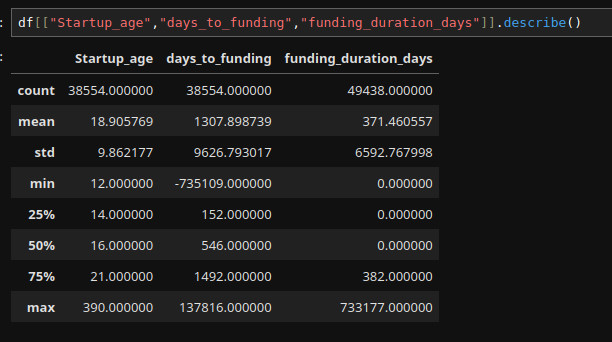


In [13]:
df[["Startup_age","days_to_funding","funding_duration_days"]].describe()

,Startup_age,days_to_funding,funding_duration_days
count,38266.000000,38259.000000,49424.000000
mean,18.316417,1223.565645,312.137605
std,5.979906,1868.999056,620.138833
min,12.000000,0.000000,0.000000
25%,14.000000,151.000000,0.000000
50%,16.000000,537.000000,0.000000
75%,20.000000,1461.000000,382.000000
max,56.000000,16302.000000,10052.000000


##Trying to decode the issue 

In [14]:
(df["founded_at"] < "1970-01-01").sum()

np.int64(0)

In [15]:
(df["first_funding_at"] < df["founded_at"]).sum()

np.int64(2727)

In [16]:
bad = df[df["first_funding_at"] < df["founded_at"]]
bad[["founded_at","first_funding_at","last_funding_at"]].sample(20, random_state=1)

,founded_at,first_funding_at,last_funding_at
24982,2012-01-01,2009-06-01,2014-04-02
42445,2014-07-01,2014-01-01,2014-01-01
29856,2011-11-11,2011-11-01,2011-11-01
31619,2010-01-01,2004-12-01,2004-12-01
24468,2011-04-10,2011-03-03,2013-06-11
19948,2013-03-01,2012-08-22,2012-08-22
8302,2012-05-16,2012-04-11,2014-10-20
18086,2013-01-11,2013-01-01,2013-01-01
11880,2013-01-01,2012-04-15,2013-06-11
40013,2012-10-23,2012-10-12,2013-11-15


In [20]:
df.to_csv("../data/processed/startup_data_prepared.csv",index=False)